# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from typing import Union, List, Iterable

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from statsmodels.regression.linear_model import OLS

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import *
from core.m_out_of_n_bootstrap import choose_best_m
from core.dgp import SingleSegment
import core.binary_treatments_single_segment as btss

# DGP

In [6]:
dgp = SingleSegment(
    te=0.6, treatment_space=np.array([0, 1]), noise_std=1
)
data = dgp.sample(sample_size=1000, seed=0)
data.head()

,outcome,treatment
0,-0.985511,0
1,-0.871835,1
2,2.248135,1
3,0.164228,0
4,1.167290,1


# Demand Model

In [7]:
pom = btss.PotentialOutcomeModel().fit(data)

print(f'True Treatment Effect: {dgp.te:.2f}')
print(f'Estimated Treatment Effect: {pom.te:.2f} ({pom.te_se:.2f})')

True Treatment Effect: 0.60
Estimated Treatment Effect: 0.73 (0.06)


# Optimization

$$
\begin{aligned}
V(\tau) & = \max\{p\tau - c, 0\} \\
& = \max\{p\tau, c\} - c \\ 
& = p \max\{\tau, c / p\} - c
\end{aligned}
$$

Optimal targeting policy $\pi$: 
$$
\pi(P, p, c) = \begin{cases}
1, \quad \text{if } \theta(P) \geq c / p \\ 
0, \quad \text{o.w.}
\end{cases}
$$

In [8]:
price, cost = 1, 0.5

plugin_decision, plugin_targ_val_est = btss.optimize(
    te=pom.te, price=price, cost=cost
)
plugin_targ_val = btss.objective_func(
    targ_decision=plugin_decision, te=dgp.te, price=price, cost=cost
)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_targ_val_est:.2f}')
print(f'True Targeting Value: {plugin_targ_val:.2f}')

Plugin Decision: True
Estimated Targeting Value: 0.23
True Targeting Value: 0.10


## Shape of Value Function

In [9]:
def plot_value_function(
    price: float, cost: float, tau_lb: float, tau_ub: float, 
): 
    tau_arr = np.linspace(tau_lb, tau_ub, 1000)
    V_arr = np.maximum(tau_arr * price - cost, 0)

    fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

    # plot valuation function
    ax.plot(tau_arr, V_arr)

    # mark discontinuous point
    ax.plot(cost / price, 0, 'r*', markersize=20, label='Nondifferentiable Point')

    # plot attributes
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.set_title('Optimal Targeting Value Function', fontsize=title_size)
    ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
    ax.set_ylabel('Optimal Targeting Value', fontsize=axis_label_size)
    ax.legend(loc='best', fontsize=legend_label_size)
    ax.grid()

    plt.tight_layout()
    plt.show()

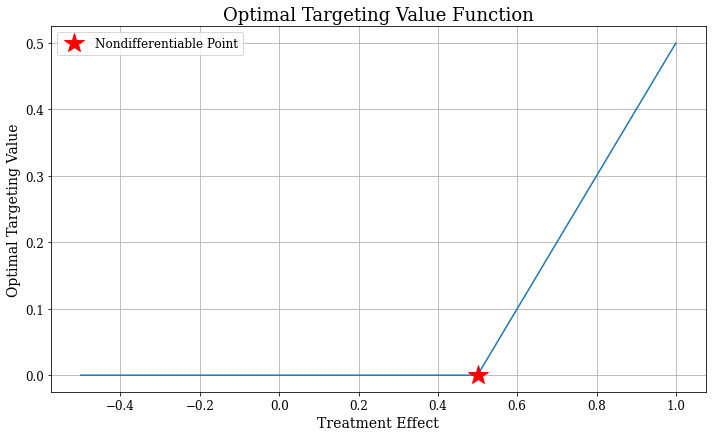

In [10]:
plot_value_function(price=1, cost=0.5, tau_lb=-0.5, tau_ub=1)

# Winner's Curse

$$
\begin{aligned}
WC(\hat{\tau}) & = \max\{p\hat{\tau} - c, 0\} - (p\tau - c) \mathbb{I}\{\hat{\tau} \geq c / p\} \\
& = p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\} \\ 
& = \begin{cases}
p (\hat{\tau} - \tau), \quad & \text{if } \hat{\tau} > c / p \\ 
0, \quad & \text{if } \hat{\tau} = c / p \\ 
0, \quad & \text{if } \hat{\tau} < c / p \\ 
\end{cases}
\end{aligned}
$$

Expected winner's curse: 
$$
WC = \mathrm{E}\left[ p (\hat{\tau} - \tau) \mathbb{I}\{\hat{\tau} \geq c / p\}\right]
$$

In [11]:
operations_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 2, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 50}

experiment_params = {'n_experiments': 1000} 

# empirical distribution of winner's curse
estimators_dict = {}

results = btss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict
)

clairvoyant_opt_obj = operations_params['price'] * dgp_params['te'] - operations_params['cost']

# emp_wc_dstn_arr = np.array([record[f'plugin_wc'] for record in results]) / clairvoyant_opt_obj
emp_wc_dstn_arr = np.array([record[f'plugin_wc'] for record in results])

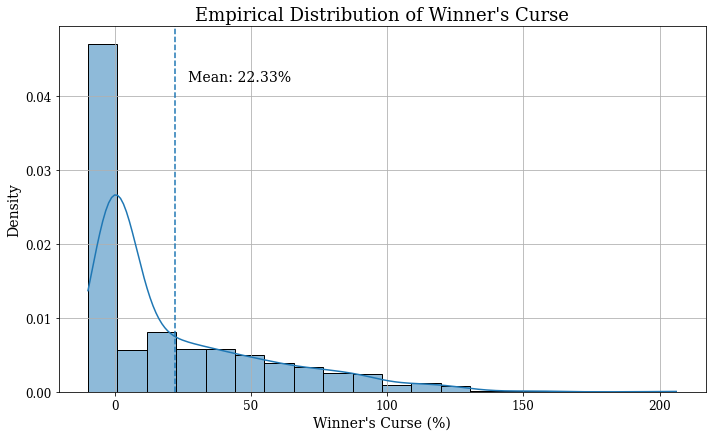

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr * 100, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(emp_wc_dstn_arr.mean() * 100, color='C0', linestyle='--')
ax.annotate(
    f"Mean: {emp_wc_dstn_arr.mean() * 100:.2f}%", 
    xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating winner's curse

In [13]:
dgp = SingleSegment(**dgp_params)
data = dgp.sample(sample_size=100, seed=0)

## Standard Bootstrap

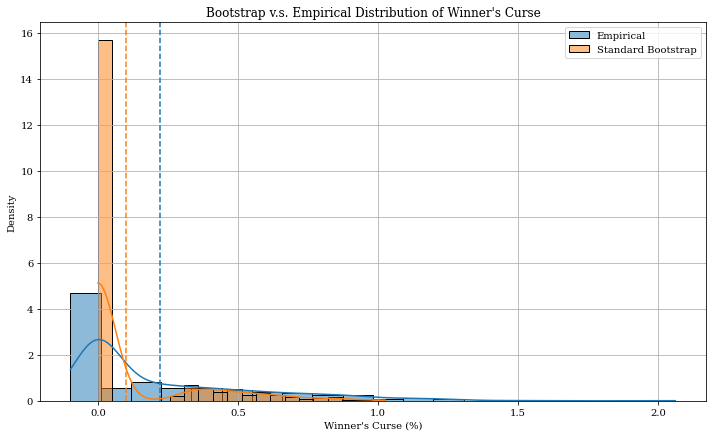

In [14]:
# generate bootstrap distribution
boot_wc_dstn_arr = btss.get_wc_boot_dstn(data, **operations_params, n_bootstraps=500)
# boot_wc_dstn_arr /= clairvoyant_opt_obj

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse (%)")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

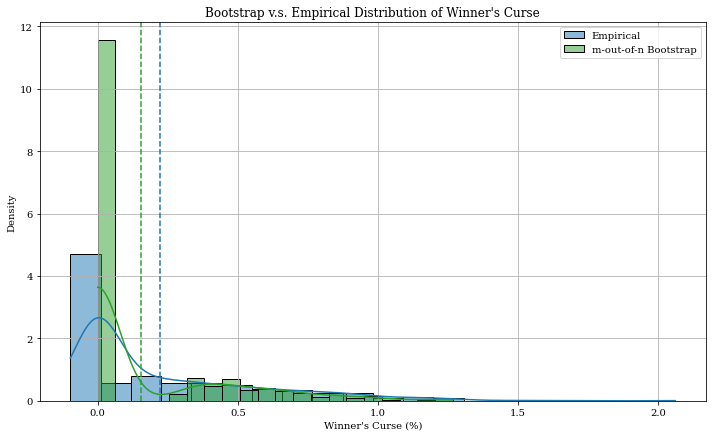

In [15]:
# generate bootstrap distribution
mn_boot_wc_dstn_arr = btss.get_wc_m_out_of_n_boot_dstn(
    data, **operations_params, 
    n_bootstraps=500, power=0.95
)
# mn_boot_wc_dstn_arr /= clairvoyant_opt_obj

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(mn_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(mn_boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse (%)")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

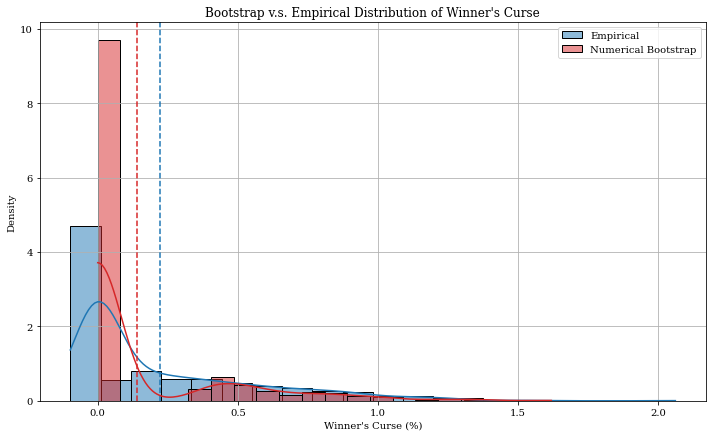

In [16]:
# generate bootstrap distribution
num_boot_wc_dstn_arr = btss.get_wc_num_boot_dstn(
    data, **operations_params, 
    n_bootstraps=500, power=-0.45
)
# num_boot_wc_dstn_arr /= clairvoyant_opt_obj

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_dstn_arr.mean(), color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse")
ax.set_xlabel("Winner's Curse (%)")
ax.set_ylabel('Density')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [21]:
targeting_params = {'price': 1, 'cost': 0.5}

dgp_params = {'te': 0.6, 'noise_std': 5, 'treatment_space': np.array([0, 1])}

data_params = {'sample_size': 500}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 1000, 'bootstrap_method': 'standard'}
    }, 
    'mnb_correction': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 5000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.9
        }
    }, 
    'numb_correction': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 5000, 'bootstrap_method': 'numerical', 
            'power': - 0.45
        }
    }
}

In [22]:
result_records = btss.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True
)

  1%|          | 8/1000 [00:57<1:59:15,  7.21s/it]


KeyboardInterrupt: 

# Sensitivity Analysis

## Number of bootstraps

In [227]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.1, 'noise_std': 5}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': np.nan, 'bootstrap_method': 'standard'}
    }, 
    'mnb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': np.nan, 'bootstrap_method': 'm_out_of_n', 
            # 'm_method': 'Bickle-Sakov', 'q': 0.95, 'max_j': 20, 'min_m': 5, 
            'm_method': 'power', 'pow': 0.95
        }
    }, 
    'numb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': np.nan, 'bootstrap_method': 'numerical', 
            'ep_bootstrap': 'standard', 'pow': - 0.45
        }
    }
}

In [228]:
num_bootstraps_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 5000]
result_dict = {num_bootstraps: None for num_bootstraps in num_bootstraps_list}

for idx, num_bootstraps in enumerate(num_bootstraps_list):
    estimators_dict['bootstrap_correction']['params']['n_bootstraps'] = num_bootstraps
    estimators_dict['mnb_correction']['params']['n_bootstraps'] = num_bootstraps
    estimators_dict['numb_correction']['params']['n_bootstraps'] = num_bootstraps

    results = repeated_experiments(
        targeting_params=targeting_params, 
        demand_params=demand_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
    )

    wc_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc'] for record in results]) 
        for name in estimators_dict.keys()
    })

    result_dict[num_bootstraps] = {
        f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
    }

    result_dict[num_bootstraps].update({
        f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_df.columns
    })

with open('results/case1_num_bootstraps_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

100%|██████████| 1000/1000 [06:03<00:00,  2.75it/s]


In [230]:
with open('results/case1_num_bootstraps_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T
result_df

,plugin_mean,bootstrap_correction_mean,mnb_correction_mean,numb_correction_mean,plugin_se,bootstrap_correction_se,mnb_correction_se,numb_correction_se
100,0.241918,0.059823,0.020092,0.007141,0.030282,0.030719,0.030648,0.031083
200,0.241918,0.059694,0.017527,0.004214,0.030282,0.030630,0.030541,0.031018
300,0.241918,0.060569,0.018605,0.004002,0.030282,0.030678,0.030634,0.030822
400,0.241918,0.060518,0.017223,0.005655,0.030282,0.030635,0.030496,0.030969
500,0.241918,0.060539,0.017066,0.005824,0.030282,0.030654,0.030537,0.031021
600,0.241918,0.060226,0.016708,0.005873,0.030282,0.030598,0.030565,0.030976
700,0.241918,0.060011,0.017104,0.005496,0.030282,0.030585,0.030547,0.031005
800,0.241918,0.059974,0.017499,0.005579,0.030282,0.030587,0.030566,0.030951
900,0.241918,0.060151,0.016734,0.005658,0.030282,0.030589,0.030509,0.030943
1000,0.241918,0.060126,0.017441,0.005551,0.030282,0.030606,0.030548,0.030887


## Hyperparameter

### m-out-of-n

In [27]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': np.nan, 'noise_std': 5}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 1000, 'bootstrap_method': 'standard'}
    }, 
    'mnb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            # 'm_method': 'Bickle-Sakov', 'q': 0.95, 'max_j': 20, 'min_m': 5, 
            'm_method': 'power', 'pow': np.nan
        }
    }, 
}

In [28]:
tau_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [0.88, 0.90, 0.92, 0.95, 0.97]
result_dict = {(tau, power): None for tau in tau_list for power in power_list}

for tau in tau_list:
    demand_params['tau'] = tau
    for power in power_list: 
        print(f'Tau = {tau}, Power = {power}')
        estimators_dict['mnb_correction']['params']['pow'] = power
        
        result_record = repeated_experiments(
            targeting_params=targeting_params, 
            demand_params=demand_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in estimators_dict.keys()
        })

        result_dict[(tau, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

Tau = -0.2, Power = 0.88


100%|██████████| 1000/1000 [00:49<00:00, 20.28it/s]


Tau = -0.2, Power = 0.9


100%|██████████| 1000/1000 [00:49<00:00, 20.23it/s]


Tau = -0.2, Power = 0.92


...

100%|██████████| 1000/1000 [00:53<00:00, 18.84it/s]


Tau = 1, Power = 0.95


100%|██████████| 1000/1000 [00:54<00:00, 18.23it/s]


Tau = 1, Power = 0.97


100%|██████████| 1000/1000 [00:51<00:00, 19.25it/s]


In [155]:
with open('results/case1_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'bootstrap_correction_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'mnb_correction_mean']]
    best_wc_list[idx] = temp['mnb_correction_mean'].loc[(-temp['mnb_correction_mean'].abs()).idxmax()]

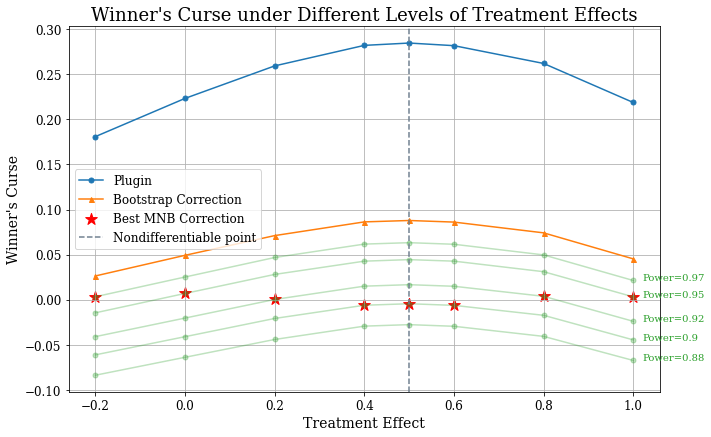

In [156]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['bootstrap_correction_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'mnb_correction_mean']]
    ax.plot(mnb_df['tau'], mnb_df['mnb_correction_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['mnb_correction_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C2'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best MNB Correction')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-mnb-hyperparam-test.png')
plt.show()

### Numerical bootstrap

In [140]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': np.nan, 'noise_std': 5}

data_params = {'sample_size': 200}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'plugin': {
        'estimator': plugin_optimize, 
        'params': {}
    }, 
    'bootstrap_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 1000, 'bootstrap_method': 'standard'}
    }, 
    'numb_correction': {
        'estimator': bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'ep_bootstrap': 'standard', 'pow': np.nan
        }
    }, 
}

In [141]:
tau_list = [-0.2, 0, 0.2, 0.4, 0.5, 0.6, 0.8, 1]
power_list = [-0.35, -0.40, -0.45, -0.49]
result_dict = {(tau, power): None for tau in tau_list for power in power_list}

for tau in tau_list:
    demand_params['tau'] = tau
    for power in power_list: 
        print(f'Tau = {tau}, Power = {power}')
        estimators_dict['numb_correction']['params']['pow'] = power
        
        result_record = repeated_experiments(
            targeting_params=targeting_params, 
            demand_params=demand_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in estimators_dict.keys()
        })

        result_dict[(tau, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case1_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

Tau = -0.2, Power = -0.35


100%|██████████| 1000/1000 [00:48<00:00, 20.43it/s]


Tau = -0.2, Power = -0.4


100%|██████████| 1000/1000 [00:49<00:00, 20.26it/s]


Tau = -0.2, Power = -0.45


...

100%|██████████| 1000/1000 [00:47<00:00, 20.91it/s]


Tau = 1, Power = -0.45


100%|██████████| 1000/1000 [00:47<00:00, 21.17it/s]


Tau = 1, Power = -0.49


100%|██████████| 1000/1000 [00:47<00:00, 21.17it/s]


In [150]:
with open('results/case1_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'bootstrap_correction_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'numb_correction_mean']]
    best_wc_list[idx] = temp['numb_correction_mean'].loc[(-temp['numb_correction_mean'].abs()).idxmax()]

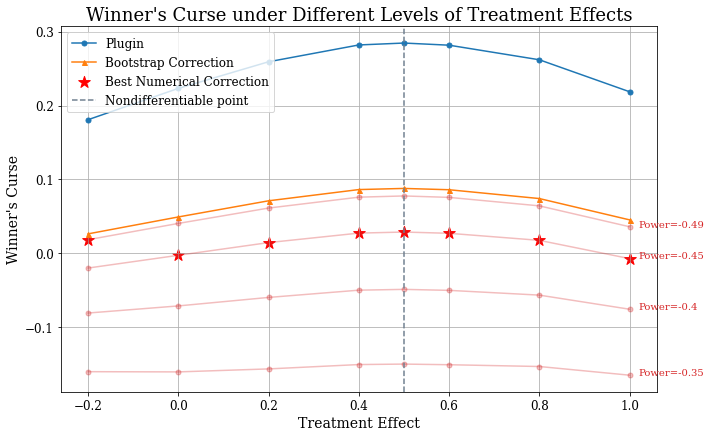

In [153]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['bootstrap_correction_mean'], '^-', markersize=5, label='Bootstrap Correction', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'numb_correction_mean']]
    ax.plot(mnb_df['tau'], mnb_df['numb_correction_mean'], 'o-', color='C3', alpha=0.3, markersize=5)
    ax.text(
        1.02, mnb_df[mnb_df['tau'] == 1.0]['numb_correction_mean'].values[0], 
        f'Power={power}', 
        fontsize=10, color='C3'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Numerical Correction')

# plot the nondifferentiable point
ax.axvline(targeting_params['cost'] / targeting_params['price'], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/case1-numb-hyperparam-test.png')
plt.show()

## Sample Size

In [161]:
targeting_params = {'price': 1, 'cost': 0.5}

demand_params = {'tau': 0.6, 'noise_std': 5}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 1000}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 1000, 'bootstrap_method': 'standard'}
    }, 
    'mnb_correction': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 5000, 'bootstrap_method': 'm_out_of_n', 
            # 'm_method': 'Bickle-Sakov', 'q': 0.95, 'max_j': 20, 'min_m': 5, 
            'm_method': 'power', 'pow': 0.9
        }
    }, 
    'numb_correction': {
        'estimator': btss.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 5000, 'bootstrap_method': 'numerical', 
            'ep_bootstrap': 'standard', 'pow': - 0.45
        }
    }
}

In [237]:
sample_size_list = [50, 100, 200, 300, 400, 500, 750, 1000]
result_dict = {sample_size: None for sample_size in sample_size_list}

for idx, sample_size in enumerate(sample_size_list):
    data_params['sample_size'] = sample_size

    results = repeated_experiments(
        targeting_params=targeting_params, 
        demand_params=demand_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
    )

    wc_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc'] for record in results]) 
        for name in estimators_dict.keys()
    })

    result_dict[sample_size] = {
        f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
    }

    result_dict[sample_size].update({
        f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_df.columns
    })

with open('results/case1_sample_size_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

100%|██████████| 1000/1000 [05:56<00:00,  2.81it/s]


In [171]:
with open('results/case1_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

baseline = targeting_params['price'] * demand_params['tau'] - targeting_params['cost']

result_df = pd.DataFrame.from_dict(result_dict).T
result_df = result_df / result_df.loc[50, 'plugin_mean']

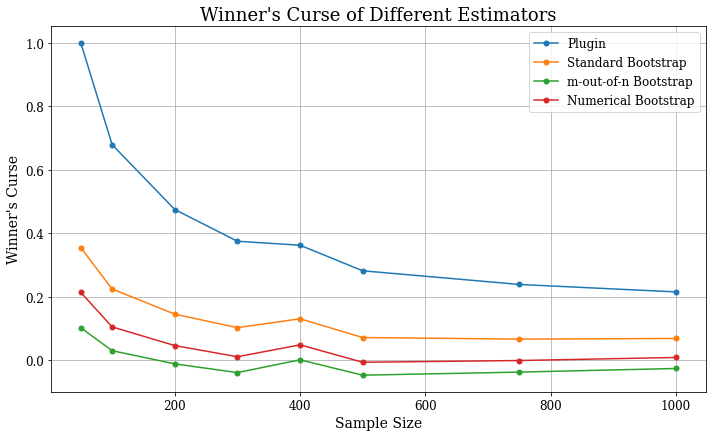

In [172]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plugin estimator
ax.plot(result_df.index, result_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')
# ax.fill_between(
#     result_df.index, 
#     result_df['plugin_mean'] - 1.96 * result_df['plugin_se'], 
#     result_df['plugin_mean'] + 1.96 * result_df['plugin_se'], 
#     color='C0', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['plugin_mean'], yerr= 1.96 * result_df['plugin_se'], 
#     fmt='o', capsize=5, label='Plugin', color='C0'
# )

# standard bootstrap 
ax.plot(result_df.index, result_df['bootstrap_correction_mean'], 'o-', markersize=5, label='Standard Bootstrap', color='C1')
# ax.fill_between(
#     result_df.index, 
#     result_df['bootstrap_correction_mean'] - 1.96 * result_df['bootstrap_correction_se'], 
#     result_df['bootstrap_correction_mean'] + 1.96 * result_df['bootstrap_correction_se'], 
#     color='C1', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['bootstrap_correction_mean'], yerr= 1.96 * result_df['bootstrap_correction_se'],
#     fmt='o', capsize=5, label='Standard Bootstrap', color='C1'
# )

# m out of n bootstrap
ax.plot(result_df.index, result_df['mnb_correction_mean'], 'o-', markersize=5, label='m-out-of-n Bootstrap', color='C2')
# ax.fill_between(
#     result_df.index, 
#     result_df['mnb_correction_mean'] - 1.96 * result_df['mnb_correction_se'], 
#     result_df['mnb_correction_mean'] + 1.96 * result_df['mnb_correction_se'], 
#     color='C2', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['mnb_correction_mean'], yerr= 1.96 * result_df['mnb_correction_se'],
#     fmt='o', capsize=5, label='m-out-of-n Bootstrap', color='C2'
# )

# numerical bootstrap
ax.plot(result_df.index, result_df['numb_correction_mean'], 'o-', markersize=5, label='Numerical Bootstrap', color='C3')
# ax.fill_between(
#     result_df.index, 
#     result_df['numb_correction_mean'] - 1.96 * result_df['numb_correction_se'], 
#     result_df['numb_correction_mean'] + 1.96 * result_df['numb_correction_se'], 
#     color='C3', alpha=0.3
# )
# ax.errorbar(
#     x=result_df.index, y=result_df['numb_correction_mean'], yerr= 1.96 * result_df['numb_correction_se'],
#     fmt='o', capsize=5, label='Numerical Bootstrap', color='C3'
# )

ax.set_title("Winner's Curse of Different Estimators", fontsize=title_size)
ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()
ax.legend(loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/case1-sample-size-test.png')
plt.show()